In [6]:
# Initialization, styling configuration, and helper utilities
%matplotlib inline

import math
import pandas as pd
import torch
from ipywidgets import interact
import ipywidgets as widgets

# Load course helper utilities (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/ML-DL/02_deep_learning/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp

import importlib
importlib.reload(hp)

hp.setup_theme()


# Single-layer Networks: Regression


## The Goal of Supervised Regression

In supervised regression, our goal is to predict a continuous target variable $t \in \mathbb{R}$ given a continuous input feature $x \in \mathbb{R}$.

Consider a synthetic data generating process where targets are generated by a true function $h(x) = \sin(2\pi x)$ corrupted by zero-mean additive Gaussian noise:
$$t = \sin(2\pi x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

Given a training set of $N$ observations $\mathcal{D} = \{(x_n, t_n)\}_{n=1}^N$, we fit a polynomial model of degree $M$:
$$y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + \dots + w_M x^M = \sum_{j=0}^M w_j x^j$$

To determine the coefficients $\mathbf{w} = (w_0, \dots, w_M)^\mathrm{T}$, we minimize the **sum-of-squares error function**:
$$E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \left(y(x_n, \mathbf{w}) - t_n\right)^2$$


In [7]:
# Generate canonical sinusoidal dataset (N = 10 training points)
torch.manual_seed(42)
N_samples = 10
noise_sigma = 0.2

x_train = torch.linspace(0.0, 1.0, N_samples)
t_true = torch.sin(2.0 * torch.pi * x_train)
t_train = t_true + noise_sigma * torch.randn(N_samples)

# Dense grid for plotting the underlying ground-truth process
x_dense = torch.linspace(0.0, 1.0, 200)
t_dense = torch.sin(2.0 * torch.pi * x_dense)

# Display transparent inputs and targets
sample_df = pd.DataFrame({'x_n': x_train.numpy(), 't_n': t_train.numpy()})
print("Training Observations (N = 10):\n", sample_df.round(3).T)


Training Observations (N = 10):
          0      1      2      3      4      5      6      7      8      9
x_n  0.000  0.111  0.222  0.333  0.444  0.556  0.667  0.778  0.889  1.000
t_n  0.067  0.669  1.032  0.912  0.117 -0.379 -0.424 -1.112 -0.550  0.053


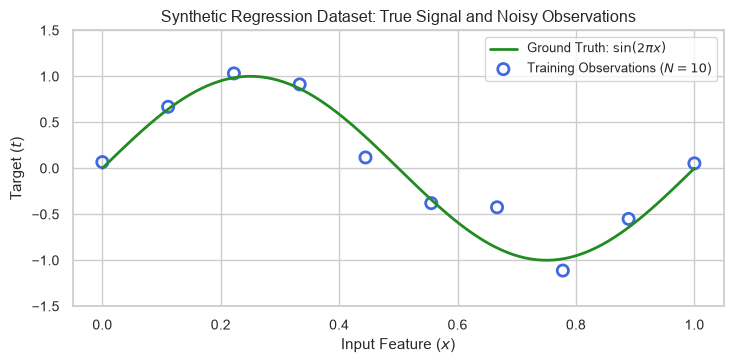

In [10]:
# Visualizing the training data and true sinusoidal signal
hp.plot_synthetic_regression_data(x_dense, t_dense, x_train, t_train)


## The Physical Analogy of Least Squares

> 💡 **Physical Analogy:** Imagine each data point connected to the model curve by a vertical elastic spring. The sum-of-squares error measures total stored potential energy. Least squares finds the curve that relaxes total spring tension to its minimum!


In [ ]:
# Interactive Residuals Callback Definition
def plot_interactive_residuals(w0=0.0, w1=0.0):
    """Interactive widget callback visualizing residuals as elastic springs pulling on a linear model."""
    f = lambda x: w0 + w1 * x
    hp.plot_residuals(f, x_train, t_train, show=False)


In [ ]:
# Interactive Exploration: Visualizing Residuals as Vertical Elastic Springs
interact(plot_interactive_residuals,
         w0=widgets.FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description="w0 (Intercept):"),
         w1=widgets.FloatSlider(min=-4.0, max=4.0, step=0.1, value=0.0, description="w1 (Slope):"));


## Model Complexity & The Overfitting Dilemma

What happens as we vary the polynomial degree $M \in \{0, 1, 3, 9\}$ on our $N = 10$ observations?

- **$M = 0$ (Constant) & $M = 1$ (Linear)**: **Underfitting (High Bias)**. The model is too rigid to flex into the shape of a sinusoid. Both training and test errors are high.
- **$M = 3$ (Cubic)**: **Optimal Balance**. The cubic polynomial has sufficient flexibility to trace the underlying sinusoid cleanly.
- **$M = 9$ (9th-Order)**: **Severe Overfitting (High Variance)**. With $M + 1 = 10$ free parameters, the polynomial has enough degrees of freedom to pass exactly through every single training point ($E_\mathrm{RMS} = 0$). However, between data points, it oscillates wildly!

> ⚠️ **Important:** As $M$ increases, training error decreases monotonically. But generalization error on independent test data explodes for large $M$.

For cross-dataset comparison, we define the **Root-Mean-Square (RMS) Error**: $E_\mathrm{RMS} = \sqrt{2 E(\mathbf{w}^*)/N}$.


In [ ]:
# Fit polynomials of degrees M in [0, 1, 3, 9] and evaluate RMS errors
degrees = [0, 1, 3, 9]
fitted_models = {}

# Independent test set for evaluation
torch.manual_seed(999)
x_test_eval = torch.rand(100)
t_test_eval = torch.sin(2.0 * torch.pi * x_test_eval) + noise_sigma * torch.randn(100)

err_records = []
for M in degrees:
    Phi_train = torch.vander(x_train, N=M + 1, increasing=True)
    w_fit = torch.linalg.lstsq(Phi_train, t_train.unsqueeze(1)).solution.reshape(-1)
    fitted_models[M] = w_fit
    
    y_tr = torch.matmul(Phi_train, w_fit)
    e_tr = torch.sqrt(torch.mean((y_tr - t_train)**2)).item()
    
    Phi_te = torch.vander(x_test_eval, N=M + 1, increasing=True)
    y_te = torch.matmul(Phi_te, w_fit)
    e_te = torch.sqrt(torch.mean((y_te - t_test_eval)**2)).item()
    err_records.append({'Degree M': M, 'Train E_RMS': round(e_tr, 3), 'Test E_RMS': round(e_te, 3)})

print(pd.DataFrame(err_records).to_string(index=False))


In [ ]:
# Visualizing polynomial fits for M in [0, 1, 3, 9]
hp.plot_polynomial_fits(x_dense, t_dense, x_train, t_train, fitted_models, degrees)


## The Anatomy of Overfitting: Explosive Weights

Why does the polynomial oscillate so violently for $M = 9$?

- **The Tug-of-War Mechanism**: To force a 9th-degree curve to pass exactly through noisy points, adjacent powers of $x$ (e.g. $w_8 x^8$ and $w_9 x^9$) enter a violent cancellation contest.
- Coefficients grow to **massive positive and negative values** that cancel out everywhere *except* right at the sample points.

| Parameter | $M = 0$ | $M = 1$ | $M = 3$ | $M = 9$ |
| :--- | :--- | :--- | :--- | :--- |
| $w_0$ | $+0.04$ | $+0.69$ | $+0.04$ | $+0.07$ |
| $w_1$ | — | $-1.30$ | $+9.70$ | $+26.60$ |
| $w_2$ | — | — | $-29.32$ | $-432.16$ |
| $w_3$ | — | — | $+19.67$ | $+3227.95$ |
| $\dots$ | — | — | — | $\dots$ |
| $w_9$ | — | — | — | $-6412.08$ |

> 💡 **Key Takeaway:** Overfitting is directly reflected in the **magnitude of the weight vector** $\|\mathbf{w}\|_2$. This provides the exact mathematical justification for weight decay regularization.


In [ ]:
# Extract and tabulate weight vectors across polynomial degrees M
table_data = {'Coeff': [f'w_{j}' for j in range(10)]}
for M in [0, 1, 3, 9]:
    w = fitted_models[M]
    vals = [f"{w[j].item():+10.2f}" if j <= M else "         —" for j in range(10)]
    table_data[f'M = {M}'] = vals

weights_df = pd.DataFrame(table_data)
print("Fitted Polynomial Coefficients Across Model Complexity M:\n")
print(weights_df.to_string(index=False))


## Remedy 1: The Mitigating Power of Dataset Size

Can we prevent overfitting without reducing our flexible model degree ($M = 9$)?

**Yes: by collecting more training data!**

- For $N = 15$: wild oscillations between points begin to dampen.
- For $N = 100$: the $M = 9$ polynomial fits the underlying sinusoid remarkably well without wild oscillations!

- *The Spring Intuition*: When 100 springs are attached to the curve, random noise pulls in opposing directions and cancels out, constraining the polynomial to the true signal.

> 💡 **Key Takeaway:** Model complexity is not an absolute property of the parameter count $M$; it depends on the **ratio of parameters to data points ($M / N$)**. Larger datasets naturally tame flexible models.


In [ ]:
# Remedy 1: Fit flexible M = 9 polynomial on larger datasets (N = 15 and N = 100)
models_by_N = []
for N_val in [15, 100]:
    torch.manual_seed(123)
    x_sc = torch.linspace(0.0, 1.0, N_val)
    t_sc = torch.sin(2.0 * torch.pi * x_sc) + noise_sigma * torch.randn(N_val)
    Phi_sc = torch.vander(x_sc, N=10, increasing=True)
    w_sc = torch.linalg.lstsq(Phi_sc, t_sc.unsqueeze(1)).solution.reshape(-1)
    y_dense_sc = torch.matmul(torch.vander(x_dense, N=10, increasing=True), w_sc)
    models_by_N.append((N_val, x_sc, t_sc, y_dense_sc))
    print(f"Fitted N = {N_val:3d} points -> Weight Norm ||w||_2 = {torch.norm(w_sc).item():.2f}")


In [ ]:
# Visualizing the Mitigating Power of Dataset Size on Overfitting
hp.plot_dataset_size_remedy(x_dense, t_dense, models_by_N)


## Remedy 2: Regularization via Weight Decay

When additional data cannot be collected, we can put a **mathematical leash on the weights**!

We augment the error function with a penalty on the squared magnitude of the weights:
$$\widetilde{E}(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N \left(y(x_n, \mathbf{w}) - t_n\right)^2 + \frac{\lambda}{2} \|\mathbf{w}\|^2$$
where $\|\mathbf{w}\|^2 = \mathbf{w}^\mathrm{T}\mathbf{w} = w_0^2 + w_1^2 + \dots + w_M^2$, and $\lambda \ge 0$ controls penalty strength.

- For $\ln\lambda = -\infty$ ($\lambda = 0$): unconstrained wild oscillations.
- For $\ln\lambda = -18$: optimal balance; smooth curve recovering the true sinusoid!
- For $\ln\lambda = 0$ ($\lambda = 1$): over-regularized; weights crushed towards zero (underfitting).

> 💡 **Key Takeaway:** Weight decay penalizes violent coefficient cancellations, preserving smoothness even for high-capacity models.


In [ ]:
# Fit regularized M = 9 polynomial on N = 10 data points
Phi_10 = torch.vander(x_train, N=10, increasing=True)
reg_lambdas = [math.exp(-18), 1.0] # ln(lambda) = -18 and 0
reg_fits = {}

for lam in reg_lambdas:
    A = torch.matmul(Phi_10.T, Phi_10) + lam * torch.eye(10)
    b = torch.matmul(Phi_10.T, t_train.unsqueeze(1))
    w_reg = torch.linalg.solve(A, b).reshape(-1)
    reg_fits[lam] = w_reg
    norm_w = torch.norm(w_reg).item()
    print(f"lambda = {lam:.2e} (ln lambda = {math.log(lam):.0f}) -> Weight Norm ||w||_2 = {norm_w:.2f}")


In [ ]:
# Visualizing regularized fits
hp.plot_regularized_fits(x_dense, t_dense, x_train, t_train, reg_fits, reg_lambdas)


# Linear Basis Function Models
## Generalizing from 1D Polynomials to Multidimensional Representations

Raw linear models express predictions as a linear combination of raw inputs $\mathbf{x} = (x_1, \dots, x_D)^\mathrm{T} \in \mathbb{R}^D$:
$$y(\mathbf{x}, \mathbf{w}) = w_0 + w_1 x_1 + \dots + w_D x_D = \mathbf{w}^\mathrm{T}\mathbf{x}$$
This severely restricts the model to flat hyperplanes.

We generalize by replacing raw inputs with fixed non-linear **basis functions** $\boldsymbol{\phi}(\mathbf{x}) \in \mathbb{R}^M$:
$$y(\mathbf{x}, \mathbf{w}) = w_0 + \sum_{j=1}^{M-1} w_j \phi_j(\mathbf{x}) = \sum_{j=0}^{M-1} w_j \phi_j(\mathbf{x}) = \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x})$$
where $\phi_0(\mathbf{x}) \equiv 1$ acts as a dummy basis function for the intercept $w_0$.

```
Input x in R^D ---> [ Fixed Non-linear Feature Map phi(x) ] ---> [ Linear Weights w ] ---> Prediction y
```

> 💡 **Single-Layer Neural Network:** The basis representation corresponds to a single-layer neural network whose input-to-feature connections are fixed, and whose feature-to-output connections are learnable parameters $\mathbf{w}$.


## Canonical Families of Basis Functions

The choice of basis functions $\phi_j(\mathbf{x})$ defines the feature representation:

1. **Polynomial Basis Functions**:
   $$\phi_j(x) = x^j$$
   Global functions; changes in one region perturb predictions everywhere.

2. **Gaussian Radial Basis Functions (RBF)**:
   $$\phi_j(\mathbf{x}) = \exp\left(-\frac{\|\mathbf{x} - \boldsymbol{\mu}_j\|^2}{2s^2}\right)$$
   Local functions; localized response centered at $\boldsymbol{\mu}_j$ with spatial scale $s$.

3. **Sigmoidal / Logistic Basis Functions**:
   $$\phi_j(\mathbf{x}) = \sigma\left(\frac{\mathbf{x} - \mu_j}{s}\right) = \frac{1}{1 + \exp\left(-\frac{\mathbf{x} - \mu_j}{s}\right)}$$
   Step-like sigmoidal transitions dividing input space into active and inactive zones.


In [ ]:
# Modular PyTorch implementations of canonical basis transformations
def polynomial_basis(x: torch.Tensor, degree: int = 3) -> torch.Tensor:
    """Compute polynomial feature expansion [1, x, x^2, ..., x^M]."""
    return torch.stack([x**i for i in range(degree + 1)], dim=1)

def gaussian_rbf_basis(x: torch.Tensor, centers: torch.Tensor, s: float = 0.15) -> torch.Tensor:
    """Compute Gaussian radial basis functions with bias column phi_0 = 1."""
    phi_0 = torch.ones_like(x).unsqueeze(1)
    phi_rbf = torch.stack([torch.exp(-0.5 * ((x - mu) / s)**2) for mu in centers], dim=1)
    return torch.cat([phi_0, phi_rbf], dim=1)

def sigmoidal_basis(x: torch.Tensor, centers: torch.Tensor, s: float = 0.15) -> torch.Tensor:
    """Compute sigmoidal (logistic) basis functions with bias column phi_0 = 1."""
    phi_0 = torch.ones_like(x).unsqueeze(1)
    phi_sig = torch.stack([torch.sigmoid((x - mu) / s) for mu in centers], dim=1)
    return torch.cat([phi_0, phi_sig], dim=1)

# Inspect sample basis representations on grid
x_eval = torch.linspace(-1.0, 1.0, 100)
centers = torch.linspace(-0.6, 0.6, 3)
phi_sample = gaussian_rbf_basis(x_eval, centers, s=0.2)
print("Design Matrix Shape Phi(x) for Gaussian RBFs:", phi_sample.shape)
print("First row Phi(x_0):", phi_sample[0].numpy().round(3))


In [ ]:
# Visualizing basis function shapes
hp.plot_basis_functions(x_eval, centers, s=0.15)


# Maximum Likelihood & Least Squares
## The Probabilistic Formulation of Regression

Assume the target variable $t$ is generated by a deterministic function $y(\mathbf{x}, \mathbf{w})$ corrupted by additive zero-mean Gaussian noise $\epsilon \sim \mathcal{N}(0, \beta^{-1})$:
$$t = y(\mathbf{x}, \mathbf{w}) + \epsilon \implies p(t \mid \mathbf{x}, \mathbf{w}, \beta) = \mathcal{N}\left(t \mid \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}), \beta^{-1}\right)$$
where $\beta = 1/\sigma^2$ is the **noise precision**.

Assuming independent observations drawn from the data distribution, the likelihood function is:
$$p(\mathbf{t} \mid \mathbf{X}, \mathbf{w}, \beta) = \prod_{n=1}^N \mathcal{N}\left(t_n \mid \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n), \beta^{-1}\right)$$

Taking the natural logarithm:
$$\ln p(\mathbf{t} \mid \mathbf{X}, \mathbf{w}, \beta) = \frac{N}{2}\ln\beta - \frac{N}{2}\ln(2\pi) - \beta E_\mathrm{D}(\mathbf{w})$$
where $E_\mathrm{D}(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N \left(t_n - \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n)\right)^2$ is the sum-of-squares error.

> 💡 **Foundation:** Maximizing log-likelihood with respect to $\mathbf{w}$ is mathematically identical to minimizing the sum-of-squares error function $E_\mathrm{D}(\mathbf{w})$!


## Deriving the Normal Equations & Intercept Separation

Setting the gradient with respect to $\mathbf{w}$ to zero:
$$\nabla_\mathbf{w} \ln p = \sum_{n=1}^N \left(t_n - \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n)\right)\boldsymbol{\phi}(\mathbf{x}_n)^\mathrm{T} = \boldsymbol{\Phi}^\mathrm{T}\mathbf{t} - \boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi}\mathbf{w} = \mathbf{0}$$
where $\boldsymbol{\Phi} \in \mathbb{R}^{N \times M}$ is the **design matrix** whose $n$-th row is $\boldsymbol{\phi}(\mathbf{x}_n)^\mathrm{T}$.

Solving for $\mathbf{w}$ yields the canonical **Normal Equations**:
$$\mathbf{w}_\mathrm{ML} = \left(\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi}\right)^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{t}$$

### Intercept Parameter Separation
If we separate the bias (intercept) parameter $w_0$ explicitly:
$$E_\mathrm{D}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \left(t_n - w_0 - \sum_{j=1}^{M-1} w_j \phi_j(\mathbf{x}_n)\right)^2$$
Setting $\frac{\partial E_\mathrm{D}}{\partial w_0} = 0$ yields:
$$w_0 = \bar{t} - \sum_{j=1}^{M-1} w_j \bar{\phi}_j$$
where $\bar{t} = \frac{1}{N}\sum_{n=1}^N t_n$ and $\bar{\phi}_j = \frac{1}{N}\sum_{n=1}^N \phi_j(\mathbf{x}_n)$ are sample means. The bias compensates for the discrepancy between the target mean and the weighted basis function averages!


## Noise Variance Estimation & Estimator Bias

Maximizing log-likelihood with respect to noise precision $\beta$ yields the maximum likelihood noise variance:
$$\frac{1}{\beta_\mathrm{ML}} = \sigma_\mathrm{ML}^2 = \frac{1}{N}\sum_{n=1}^N \left(t_n - \mathbf{w}_\mathrm{ML}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n)\right)^2 = \frac{2}{N} E_\mathrm{D}(\mathbf{w}_\mathrm{ML})$$

**Estimator Bias (Degrees of Freedom)**:
- In linear regression with $M$ basis functions, the $M$ parameters fit the noise, yielding:
$$\mathbb{E}[\sigma_\mathrm{ML}^2] = \frac{N - M}{N} \sigma^2$$

> 📘 **Unbiased Estimator:** To obtain an unbiased estimate of noise variance, divide the sum of squared residuals by $N - M$ degrees of freedom:
$$\sigma_\mathrm{unbiased}^2 = \frac{1}{N - M}\sum_{n=1}^N \left(t_n - \mathbf{w}_\mathrm{ML}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n)\right)^2$$


## Geometry of Least Squares: Orthogonal Projection

Least squares admits an illuminating geometric interpretation in $N$-dimensional sample space $\mathbb{R}^N$:

- The target vector $\mathbf{t} = (t_1, \dots, t_N)^\mathrm{T}$ is a point in $\mathbb{R}^N$.
- Each column $\boldsymbol{\phi}_j$ of design matrix $\boldsymbol{\Phi}$ is an $N$-dimensional vector in $\mathbb{R}^N$.
- The prediction vector $\mathbf{y} = \boldsymbol{\Phi}\mathbf{w}_\mathrm{ML}$ is a linear combination of these columns, lying in the $M$-dimensional subspace $\mathcal{S} \subset \mathbb{R}^N$.

```
        t (Target Vector in R^N)
       /|
      / |
     /  |  e = t - y (Residual vector, strictly orthogonal to S)
    /   |
   +----> y = Phi w_ML (Orthogonal projection of t onto subspace S)
  0     |
 ---------------------------------- Subspace S = Col(Phi) (Dimension M)
```

Minimizing $\|\mathbf{t} - \mathbf{y}\|^2$ corresponds to the **orthogonal projection** of $\mathbf{t}$ onto subspace $\mathcal{S}$.


## The Projection Matrix & Residual Orthogonality

### The Orthogonal Projection Matrix
Substituting $\mathbf{w}_\mathrm{ML} = (\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{t}$ into $\mathbf{y} = \boldsymbol{\Phi}\mathbf{w}_\mathrm{ML}$:
$$\mathbf{y} = \boldsymbol{\Phi}\left(\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi}\right)^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{t} = \mathbf{P}\mathbf{t}$$
where $\mathbf{P} = \boldsymbol{\Phi}(\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\mathrm{T}$ is the **orthogonal projection operator** onto $\mathcal{S}$.

**Algebraic Properties of $\mathbf{P}$**:
- **Idempotence**: $\mathbf{P}^2 = \mathbf{P}$ (projecting a second time leaves the vector unchanged).
- **Symmetry**: $\mathbf{P}^\mathrm{T} = \mathbf{P}$.

### Exact Orthogonality of Residuals
The residual error vector $\mathbf{e} = \mathbf{t} - \mathbf{y}$ is strictly orthogonal to every basis vector in $\mathcal{S}$:
$$\boldsymbol{\Phi}^\mathrm{T}\left(\mathbf{t} - \mathbf{y}\right) = \mathbf{0}$$

> 💡 **Key Takeaway:** The Normal Equations state that optimal predictions leave zero residual correlation with any of the basis features.


In [ ]:
# Solve Normal Equations with Gaussian RBF Basis and verify Orthogonal Projection
rbf_centers = torch.linspace(0.1, 0.9, 4)
Phi_rbf_train = gaussian_rbf_basis(x_train, rbf_centers, s=0.2) # Shape: (10, 5)
N_pts, M_basis = Phi_rbf_train.shape

# Analytical Normal Equations: w_ML = (Phi^T Phi)^(-1) Phi^T t
w_ml = torch.linalg.solve(Phi_rbf_train.T @ Phi_rbf_train, Phi_rbf_train.T @ t_train.unsqueeze(1)).reshape(-1)
y_pred = Phi_rbf_train @ w_ml
residuals = t_train - y_pred

# Maximum likelihood and unbiased noise variance estimates
sigma2_ml = torch.mean(residuals**2).item()
sigma2_unbiased = (torch.sum(residuals**2) / (N_pts - M_basis)).item()

print("Estimated Weights w_ML:", w_ml.numpy().round(3))
print(f"Noise Variance ML: {sigma2_ml:.4f} | Unbiased (N - M): {sigma2_unbiased:.4f} | True sigma^2: {noise_sigma**2:.4f}")

# Theoretical Unit Test 1: Verify Orthogonality of Residuals Phi^T (t - y) = 0
orthogonality_error = torch.norm(Phi_rbf_train.T @ residuals).item()
print(f"Orthogonality check (||Phi^T e|| < 1e-6): {orthogonality_error < 1e-6} (norm = {orthogonality_error:.2e})")


In [ ]:
# Empirical Case Study: Advertising Dataset (Tabular Regression)
adv = pd.read_csv('../../shared/data/Advertising.csv', dtype=float)
if 'Unnamed: 0' in adv.columns:
    adv = adv.drop(columns=['Unnamed: 0'])

X_raw = torch.tensor(adv[['TV', 'Radio', 'Newspaper']].values, dtype=torch.float32)
t_sales = torch.tensor(adv['Sales'].values, dtype=torch.float32).unsqueeze(1)

# Model A: Standard Linear Model
Phi_A = torch.cat([torch.ones(X_raw.shape[0], 1), X_raw], dim=1)
w_A = torch.linalg.solve(Phi_A.T @ Phi_A, Phi_A.T @ t_sales)
r2_A = 1.0 - (torch.sum((t_sales - Phi_A @ w_A)**2) / torch.sum((t_sales - t_sales.mean())**2)).item()

# Model B: Adding Non-linear Interaction Term (TV * Radio)
tv_radio_interaction = (X_raw[:, 0:1] * X_raw[:, 1:2])
Phi_B = torch.cat([torch.ones(X_raw.shape[0], 1), X_raw, tv_radio_interaction], dim=1)
w_B = torch.linalg.solve(Phi_B.T @ Phi_B, Phi_B.T @ t_sales)
r2_B = 1.0 - (torch.sum((t_sales - Phi_B @ w_B)**2) / torch.sum((t_sales - t_sales.mean())**2)).item()

print(f"Linear Model A Goodness-of-Fit R^2       : {r2_A:.4f} (89.7% explained)")
print(f"Interaction Model B Goodness-of-Fit R^2  : {r2_B:.4f} (96.8% explained - Synergistic effect!)")


# Sequential Learning: The LMS Algorithm
## Streaming Optimization for Real-Time and Massive Datasets

Batch normal equations require inverting the $M \times M$ matrix $\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi}$, incurring $\mathcal{O}(M^3)$ compute and requiring all $N$ observations in memory simultaneously.

In **sequential (online) learning**, data points are processed one at a time, and parameters are updated incrementally.

Stochastic Gradient Descent (SGD) on instantaneous squared error $E_n = \frac{1}{2}(t_n - \mathbf{w}^\mathrm{T}\boldsymbol{\phi}_n)^2$:
$$\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \eta \nabla E_n = \mathbf{w}^{(\tau)} + \eta \left(t_n - \mathbf{w}^{(\tau)\mathrm{T}}\boldsymbol{\phi}_n\right)\boldsymbol{\phi}_n$$
where $\tau$ is the step index and $\eta > 0$ is the learning rate.

This celebrated update rule is the **Widrow-Hoff delta rule** or **LMS (Least-Mean-Squares) algorithm** (Widrow & Hoff, 1960).

<small>📖 *Source: [Widrow, B., & Hoff, M. E. (1960). Adaptive switching circuits. 1960 IRE WESCON Convention Record, 4, 96–104](https://doi.org/10.21236/ad0241531)*</small>


## Adaline: Adaptive Linear Neuron

In 1960, Bernard Widrow and Ted Hoff introduced **Adaline** (Adaptive Linear Neuron) as the first practical adaptive linear machine.

**Crucial Distinction from Rosenblatt's Perceptron**:
- *Perceptron (1958)*: Computes weight updates on thresholded discrete binary predictions $f(\mathbf{w}^\mathrm{T}\mathbf{x}) \in \{-1, +1\}$. If an observation is on the correct side of the boundary, updates stop.
- *Adaline (1960)*: Computes errors directly on **continuous real-valued activations** $y_n = \mathbf{w}^\mathrm{T}\boldsymbol{\phi}_n$ before any thresholding:
$$e_n = t_n - \mathbf{w}^\mathrm{T}\boldsymbol{\phi}_n$$

```
Inputs x_i ---> [ Sum: w^T phi(x) ] ---> Continuous Activation y ---> Error: t - y (Drives weight updates)
                                                  |
                                                  v
                                          [ Threshold: sign(y) ] ---> Discrete Class (+1 / -1)
```


In [ ]:
# Implementation of the Streaming AdaLine Architecture
class StreamingAdaLine:
    """Adaptive Linear Neuron (Adaline) with online streaming LMS updates (Widrow & Hoff, 1960)."""
    def __init__(self, n_features: int, lr: float = 0.02):
        self.w = torch.zeros(n_features, 1)
        self.lr = lr
        self.epoch_snapshots = [self.w.clone()]

    def update_sample(self, phi_n: torch.Tensor, t_n: torch.Tensor):
        """Pure sample-by-sample LMS update: w <- w + lr * (t_n - y_n) * phi_n"""
        y_n = torch.matmul(phi_n, self.w) # (1, 1)
        error = t_n - y_n
        self.w += self.lr * torch.matmul(phi_n.T, error)


In [ ]:
# Online Streaming Optimization & Convergence Verification
torch.manual_seed(42)
X_synth = torch.linspace(0, 4, 30).unsqueeze(1)
Phi_synth = torch.cat([torch.ones(30, 1), X_synth], dim=1)
t_synth = 1.5 + 2.0 * X_synth.squeeze() + 0.3 * torch.randn(30)

# Analytical Batch Normal Equations baseline
w_analytic = torch.linalg.solve(Phi_synth.T @ Phi_synth, Phi_synth.T @ t_synth.unsqueeze(1)).reshape(-1)

# Streaming online training over 15 passes
adaline = StreamingAdaLine(n_features=2, lr=0.01)
for epoch in range(1, 16):
    for idx in torch.randperm(30):
        adaline.update_sample(Phi_synth[idx:idx+1], t_synth[idx:idx+1].unsqueeze(1))
    if epoch in [1, 3, 15]:
        adaline.epoch_snapshots.append((epoch, adaline.w.clone().reshape(-1)))

w_online = adaline.w.reshape(-1)
print(f"Analytical Batch Solution w_ML: [w_0 = {w_analytic[0]:.3f}, w_1 = {w_analytic[1]:.3f}]")
print(f"Online Streaming Adaline w    : [w_0 = {w_online[0]:.3f}, w_1 = {w_online[1]:.3f}]")
print(f"Convergence Error ||w_online - w_analytic||: {torch.norm(w_online - w_analytic).item():.4f}")


In [ ]:
# Visualizing Online Streaming LMS Convergence
x_line = torch.linspace(0, 4, 100)
Phi_line = torch.stack([torch.ones(100), x_line], dim=1)
hp.plot_streaming_adaline_convergence(X_synth, t_synth, x_line, Phi_line, adaline.epoch_snapshots, w_analytic)


# Regularized Least Squares
## Weight Decay and the MAP Bayesian Interpretation

Total regularized error function:
$$E(\mathbf{w}) = E_\mathrm{D}(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^\mathrm{T}\mathbf{w} = \frac{1}{2} \sum_{n=1}^N \left(t_n - \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x}_n)\right)^2 + \frac{\lambda}{2} \mathbf{w}^\mathrm{T}\mathbf{w}$$

Setting $\nabla E(\mathbf{w}) = \mathbf{0}$ yields the **Regularized Normal Equations**:
$$\mathbf{w}_\mathrm{reg} = \left(\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi} + \lambda \mathbf{I}\right)^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{t}$$

**Bayesian Maximum A Posteriori (MAP) Interpretation**:
- Prior over weights: $p(\mathbf{w}) = \mathcal{N}\left(\mathbf{w} \mid \mathbf{0}, \alpha^{-1}\mathbf{I}\right)$.
- Likelihood: $p(\mathbf{t} \mid \mathbf{w}) = \mathcal{N}\left(\mathbf{t} \mid \boldsymbol{\Phi}\mathbf{w}, \beta^{-1}\mathbf{I}\right)$.
- Maximizing posterior density $p(\mathbf{w} \mid \mathbf{t}) \propto p(\mathbf{t} \mid \mathbf{w}) p(\mathbf{w})$ is strictly equivalent to regularized least squares with regularization parameter $\lambda = \alpha / \beta$.


In [ ]:
# Numerical Conditioning Analysis: Ridge Regularization as Spectral Stabilizer
Phi_poly = torch.vander(torch.linspace(0, 1, 15), N=8, increasing=True)
A_unreg = Phi_poly.T @ Phi_poly
A_reg = A_unreg + 1e-3 * torch.eye(8)

cond_unreg = torch.linalg.cond(A_unreg).item()
cond_reg = torch.linalg.cond(A_reg).item()

print(f"Condition Number Unregularized : {cond_unreg:.2e} (Ill-conditioned! Sensitive to noise)")
print(f"Condition Number Regularized (1e-3): {cond_reg:.2e} (Stabilized! Shifted spectrum)")
print(f"Smallest Eigenvalue unreg: {torch.linalg.eigvalsh(A_unreg).min().item():.2e} -> reg: {torch.linalg.eigvalsh(A_reg).min().item():.2e}")


## Generalized $L_q$ Regularizers & Sparsity Geometry

Consider a generalized penalty of the form $\frac{\lambda}{2}\sum_{j=1}^{M-1} |w_j|^q$:
- $q = 2$: Quadratic / Ridge regression / Weight decay.
- $q = 1$: **Lasso ($L_1$) regression**.

**The Geometry of Sparsity**:
- Regularized minimization is equivalent to minimizing unconstrained error $E_\mathrm{D}(\mathbf{w})$ subject to constraint $\sum |w_j|^q \le \eta$.
- For $q = 2$ (smooth hypersphere): contours touch generically off-axis $\implies$ all weights remain non-zero.
- For $q = 1$ (diamond polytope): contours touch generically at sharp corners on coordinate axes $\implies$ weights are set to **exact zeros**!

> 💡 **Key Takeaway:** $L_1$ regularization performs automatic feature selection and produces sparse models.


In [ ]:
# Visualizing the Geometry of Sparsity: L1 (Diamond) vs L2 (Circle)
hp.plot_l1_l2_sparsity_geometry()


## Multiple Target Outputs: The Decoupling Principle

**Why do we need this?** Real-world applications often predict $K > 1$ continuous targets simultaneously: $\mathbf{t} = (t_1, \dots, t_K)^\mathrm{T} \in \mathbb{R}^K$ (e.g. predicting 3D coordinates $(x, y, z)$ or multi-channel sensor outputs).

**The Model**: $\mathbf{y}(\mathbf{x}, \mathbf{W}) = \mathbf{W}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x})$, where $\mathbf{W} \in \mathbb{R}^{M \times K}$ is a parameter matrix.

**The Natural Concern**: If the target variables have correlated noise (governed by a full noise covariance matrix $\boldsymbol{\Sigma}$), do we need to jointly invert an enormous $KM \times KM$ coupled block matrix?

**How It Works (The Decoupling Insight)**:
- In Gaussian models, the maximum likelihood estimate of the mean is **statistically decoupled from the covariance matrix**.
- Because all $K$ target outputs share the same input basis functions $\boldsymbol{\phi}(\mathbf{x})$, the joint problem decomposes into **$K$ independent linear regression problems**:
$$\mathbf{W}_\mathrm{ML} = \left(\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi}\right)^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{T}$$
where $\mathbf{T} \in \mathbb{R}^{N \times K}$ is the target matrix.

> 💡 **Key Takeaway:** We can solve for each target output dimension completely independently using standard normal equations, without inverting coupled joint covariance matrices!


In [ ]:
# Theoretical Unit Test 2: Numerical Verification of Decoupling Theorem
torch.manual_seed(42)
N_pts, M_feats = 50, 4
Phi_sim = torch.randn(N_pts, M_feats)

# Correlated noise between two target outputs
true_W = torch.tensor([[1.0, -1.0], [2.0, 0.5], [-1.5, 3.0], [0.5, 1.0]])
correlated_noise = torch.randn(N_pts, 2) @ torch.tensor([[1.0, 0.8], [0.0, 0.6]]).T
T_sim = Phi_sim @ true_W + 0.2 * correlated_noise # Shape: (50, 2)

# Joint Matrix Solve
W_joint = torch.linalg.solve(Phi_sim.T @ Phi_sim, Phi_sim.T @ T_sim)

# Separate 1D Solves
w_target1 = torch.linalg.solve(Phi_sim.T @ Phi_sim, Phi_sim.T @ T_sim[:, 0:1])
w_target2 = torch.linalg.solve(Phi_sim.T @ Phi_sim, Phi_sim.T @ T_sim[:, 1:2])
W_separate = torch.cat([w_target1, w_target2], dim=1)

decoupling_err = torch.max(torch.abs(W_joint - W_separate)).item()
print(f"Decoupling Theorem Check (||W_joint - W_separate|| < 1e-6): {decoupling_err < 1e-6} (err = {decoupling_err:.2e})")
print("Target 1 Weights (Joint vs Separate):", W_joint[:, 0].numpy().round(3), "vs", w_target1.squeeze().numpy().round(3))


# Decision Theory for Regression
## Optimal Point Predictions under Uncertainty

In probabilistic modeling, we infer the full conditional distribution $p(t \mid \mathbf{x})$.
However, practical decision-making requires committing to a single point prediction $y(\mathbf{x})$.

Decision theory formalizes this choice by specifying a loss function $L(t, y(\mathbf{x}))$ and choosing $y(\mathbf{x})$ to minimize the **expected loss**:
$$\mathbb{E}[L] = \iint L(t, y(\mathbf{x})) p(\mathbf{x}, t) \mathrm{d}\mathbf{x} \mathrm{d}t$$

For canonical **squared error loss** $L(t, y(\mathbf{x})) = (y(\mathbf{x}) - t)^2$:
$$\mathbb{E}[L] = \iint \left(y(\mathbf{x}) - t\right)^2 p(\mathbf{x}, t) \mathrm{d}\mathbf{x} \mathrm{d}t$$

Setting the functional derivative $\frac{\delta \mathbb{E}[L]}{\delta y(\mathbf{x})} = 0$ via the calculus of variations:
$$2 \int \left(y(\mathbf{x}) - t\right) p(\mathbf{x}, t) \mathrm{d}t = 0 \implies y^*(\mathbf{x}) = \frac{\int t p(\mathbf{x}, t)\mathrm{d}t}{p(\mathbf{x})} = \int t p(t \mid \mathbf{x})\mathrm{d}t = \mathbb{E}[t \mid \mathbf{x}]$$

> 📘 **Fundamental Theorem:** Under squared loss, the optimal point prediction is the **conditional expectation (regression function)** $y^*(\mathbf{x}) = \mathbb{E}[t \mid \mathbf{x}]$.


## Decomposition of Squared Loss: Reducible vs. Irreducible Error

We can expand the squared difference $(y(\mathbf{x}) - t)^2$ around the conditional mean $\mathbb{E}[t \mid \mathbf{x}]$:
$$\left(y(\mathbf{x}) - t\right)^2 = \left(\{y(\mathbf{x}) - \mathbb{E}[t \mid \mathbf{x}]\} + \{\mathbb{E}[t \mid \mathbf{x}] - t\}\right)^2$$

Taking the expectation with respect to $p(t \mid \mathbf{x})$, the cross-term vanishes because $\mathbb{E}[t - \mathbb{E}[t \mid \mathbf{x}]] = 0$. The expected loss decomposes into:
$$\mathbb{E}[L] = \underbrace{\int \left(y(\mathbf{x}) - \mathbb{E}[t \mid \mathbf{x}]\right)^2 p(\mathbf{x})\mathrm{d}\mathbf{x}}_{\text{Reducible Model Error}} + \underbrace{\int \mathrm{var}[t \mid \mathbf{x}] p(\mathbf{x})\mathrm{d}\mathbf{x}}_{\text{Irreducible Intrinsic Noise Variance}}$$

- **Reducible Model Error**: Represents model discrepancy from the true regression function. Non-negative, minimized to 0 if and only if $y(\mathbf{x}) = \mathbb{E}[t \mid \mathbf{x}]$.
- **Irreducible Intrinsic Noise**: Represents inherent uncertainty in the data generating process (aleatoric noise). Cannot be eliminated by any learning algorithm.


## Generalized Loss: The Minkowski Metric & Three Approaches

A natural generalization of squared loss is the **Minkowski loss**: $L_q(t, y(\mathbf{x})) = |y(\mathbf{x}) - t|^q, \quad q > 0$.

The choice of exponent $q$ determines which statistical property of $p(t \mid \mathbf{x})$ is predicted:
- **$q = 2$ (Squared Loss)**: Predicts the **conditional mean** $\mathbb{E}[t \mid \mathbf{x}]$. Sensitive to distant outliers.
- **$q = 1$ (Absolute Loss / MAE)**: Predicts the **conditional median** $\mathrm{median}(t \mid \mathbf{x})$. Robust to outliers.
- **$q \to 0$**: Predicts the **conditional mode** (most probable value).

**The Three Paradigms for Solving Regression**:
1. *Generative Models*: Model joint density $p(\mathbf{x}, t)$, marginalize to find $p(t \mid \mathbf{x})$, then compute $\mathbb{E}[t \mid \mathbf{x}]$.
2. *Discriminative Models*: Model conditional density $p(t \mid \mathbf{x})$ directly, then compute $\mathbb{E}[t \mid \mathbf{x}]$.
3. *Direct Regression Mapping*: Find mapping $y(\mathbf{x})$ directly from inputs without evaluating probability distributions.


In [ ]:
# Software Engineering Lesson: Robustness to Outliers (L2 Squared vs L1 Absolute Loss)
torch.manual_seed(42)
x_clean = torch.linspace(0, 1, 20).unsqueeze(1)
t_clean = 1.0 + 2.0 * x_clean.squeeze() + 0.1 * torch.randn(20)

# Inject extreme outlier sensor spikes
t_corrupt = t_clean.clone()
t_corrupt[4] += 3.5
t_corrupt[14] -= 3.0

# L2 Fit (Analytical Least Squares)
Phi_corrupt = torch.cat([torch.ones(20, 1), x_clean], dim=1)
w_l2 = torch.linalg.solve(Phi_corrupt.T @ Phi_corrupt, Phi_corrupt.T @ t_corrupt.unsqueeze(1)).reshape(-1)

# L1 Fit (Median via subgradient optimization)
w_l1 = torch.zeros(2, 1, requires_grad=True)
opt = torch.optim.Adam([w_l1], lr=0.05)
for _ in range(600):
    loss = torch.sum(torch.abs(t_corrupt.unsqueeze(1) - Phi_corrupt @ w_l1))
    opt.zero_grad()
    loss.backward()
    opt.step()

w_l1_res = w_l1.detach().reshape(-1)
print("Ground Truth Model: y = 1.00 + 2.00 * x")
print(f"L2 Solution (Mean)  : y = {w_l2[0]:.2f} + {w_l2[1]:.2f} * x (Skewed by outliers)")
print(f"L1 Solution (Median): y = {w_l1_res[0]:.2f} + {w_l1_res[1]:.2f} * x (Robust to outliers!)")


In [ ]:
# Visualizing L1 vs L2 outlier sensitivity
x_plot = torch.linspace(0, 1, 100)
Phi_plot = torch.stack([torch.ones(100), x_plot], dim=1)
hp.plot_l1_l2_outlier_comparison(x_clean, t_corrupt, x_plot, Phi_plot @ w_l2, Phi_plot @ w_l1_res)


# The Bias–Variance Trade-Off
## Decomposing Generalization Error across Datasets

Consider training a model $y(\mathbf{x}; \mathcal{D})$ on a specific dataset $\mathcal{D}$ drawn from true distribution $p(\mathbf{x}, t)$.

For a given input $\mathbf{x}$, the expected squared difference between the model and the true regression function $h(\mathbf{x}) = \mathbb{E}[t \mid \mathbf{x}]$ across all possible datasets $\mathcal{D}$ decomposes as:
$$\mathbb{E}_\mathcal{D}\left[\left(y(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\right)^2\right] = \underbrace{\left(\mathbb{E}_\mathcal{D}[y(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\right)^2}_{(\mathrm{bias})^2} + \underbrace{\mathbb{E}_\mathcal{D}\left[\left(y(\mathbf{x}; \mathcal{D}) - \mathbb{E}_\mathcal{D}[y(\mathbf{x}; \mathcal{D})]\right)^2\right]}_{\mathrm{variance}}$$

Integrating over the input distribution $p(\mathbf{x})$ and adding irreducible noise $\sigma^2$:
$$\text{Expected Test Loss} = (\text{Bias})^2 + \text{Variance} + \text{Noise}$$

- **Bias**: Approximation error caused by overly rigid model assumptions (underfitting).
- **Variance**: Sensitivity of the model to the specific random sample fluctuations in dataset $\mathcal{D}$ (overfitting).


In [ ]:
# Vectorized Monte Carlo Simulation: 100-dataset sinusoidal experiment
def setup_bias_variance_experiment(L=100, N=25, M=24, noise_std=0.2):
    """Generates L independent datasets and precomputes design matrices."""
    torch.manual_seed(42)
    true_fn = lambda x: torch.sin(2.0 * torch.pi * x)
    
    x_dense = torch.linspace(0.0, 1.0, 150)
    y_true_dense = true_fn(x_dense)
    
    mu = torch.linspace(0.0, 1.0, M)
    s = 0.1
    
    def get_phi(x_in):
        diff = x_in.unsqueeze(-1) - mu
        phi_rbf = torch.exp(-0.5 * (diff / s)**2)
        phi_0 = torch.ones_like(x_in).unsqueeze(-1)
        return torch.cat([phi_0, phi_rbf], dim=-1)
    
    Phi_dense = get_phi(x_dense) # (150, M + 1)
    x_train = torch.rand(L, N)
    t_train = true_fn(x_train) + noise_std * torch.randn(L, N)
    Phi_train = get_phi(x_train) # (L, N, M + 1)
    
    return x_dense, y_true_dense, Phi_dense, Phi_train, t_train, M

def evaluate_ensemble_fits(ln_lams_eval=[2.0, -0.5, -4.0], L=100, N=25, M=24, noise_std=0.2):
    """Fits models across L datasets for specific ln(lambda) values and extracts dense predictions."""
    x_dense, y_true_dense, Phi_dense, Phi_train, t_train, M = setup_bias_variance_experiment(L, N, M, noise_std)
    ensemble_results = {}
    
    for ln_lam in ln_lams_eval:
        lam = math.exp(ln_lam)
        reg_mat = lam * torch.eye(M + 1).unsqueeze(0)
        A = torch.bmm(Phi_train.transpose(1, 2), Phi_train) + reg_mat
        b = torch.bmm(Phi_train.transpose(1, 2), t_train.unsqueeze(-1))
        w = torch.linalg.solve(A, b) # (L, M + 1, 1)
        preds = (Phi_dense @ w).squeeze(-1) # (L, 150)
        ensemble_results[ln_lam] = (preds, preds.mean(dim=0))
        
    return x_dense, y_true_dense, ensemble_results

def compute_bias_variance_curve(L=100, N=25, M=24, noise_std=0.2):
    """Evaluates squared bias, variance, and test error across a dense sweep of ln(lambda)."""
    x_dense, y_true_dense, Phi_dense, Phi_train, t_train, M = setup_bias_variance_experiment(L, N, M, noise_std)
    ln_lambdas = torch.linspace(-4.5, 3.0, 25).tolist()
    bias2_list, var_list, test_err_list = [], [], []
    
    for ln_lam in ln_lambdas:
        lam = math.exp(ln_lam)
        reg_mat = lam * torch.eye(M + 1).unsqueeze(0)
        A = torch.bmm(Phi_train.transpose(1, 2), Phi_train) + reg_mat
        b = torch.bmm(Phi_train.transpose(1, 2), t_train.unsqueeze(-1))
        w = torch.linalg.solve(A, b)
        preds = (Phi_dense @ w).squeeze(-1)
        mean_pred = preds.mean(dim=0)
        
        bias2 = torch.mean((mean_pred - y_true_dense)**2).item()
        var = torch.mean(torch.var(preds, dim=0, unbiased=False)).item()
        bias2_list.append(bias2)
        var_list.append(var)
        test_err_list.append(bias2 + var + noise_std**2)
        
    return ln_lambdas, bias2_list, var_list, test_err_list


In [ ]:
# Visualizing Ensemble of Fits across Regularization Strengths
x_dense_ev, y_true_ev, ensembles = evaluate_ensemble_fits(ln_lams_eval=[2.0, -0.5, -4.0])
hp.plot_ensemble_fits(x_dense_ev, y_true_ev, ensembles)


In [ ]:
# The Canonical U-shaped Bias-Variance Trade-Off Curve
ln_lambdas, bias2_list, var_list, test_err_list = compute_bias_variance_curve()
total_bv = [b + v for b, v in zip(bias2_list, var_list)]
hp.plot_bias_variance_curve(ln_lambdas, bias2_list, var_list, total_bv)


In [ ]:
# Interactive Exploration Callback Definition
def plot_interactive_bias_variance(N_pts=25, noise=0.2):
    """Interactive widget callback for visualizing bias-variance trade-off across sample size and noise."""
    ln_lams, b2, v, _ = compute_bias_variance_curve(L=50, N=N_pts, M=24, noise_std=noise)
    hp.plot_bias_variance_curve(ln_lams, b2, v, [b + val for b, val in zip(b2, v)])


In [ ]:
# Interactive Exploration: Sweeping Regularization ln(lambda) and Sample Size N
interact(plot_interactive_bias_variance,
         N_pts=widgets.IntSlider(min=10, max=80, step=10, value=25, description="Samples N:"),
         noise=widgets.FloatSlider(min=0.05, max=0.4, step=0.05, value=0.2, description="Noise:"));


# Summary & Transition to Deep Neural Networks

### Core Principles Mastered
1. **Linear Basis Models**: Non-linear representations $y(\mathbf{x}, \mathbf{w}) = \mathbf{w}^\mathrm{T}\boldsymbol{\phi}(\mathbf{x})$ preserving convex analytical optimization.
2. **Overfitting & Weight Explosion**: Flexible models overfit by inflating coefficients into extreme opposing cancellations; weight decay tames this complexity.
3. **Maximum Likelihood**: Equivalent to least squares under Gaussian noise, yielding the normal equations $\mathbf{w}_\mathrm{ML} = (\boldsymbol{\Phi}^\mathrm{T}\boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\mathrm{T}\mathbf{t}$ and orthogonal projection geometry.
4. **Sequential Learning (LMS / Adaline)**: Stochastic updates optimize weights sample-by-sample without $\mathcal{O}(M^3)$ matrix inversions.
5. **Decision Theory**: Optimal point predictions under squared loss converge to the conditional mean $\mathbb{E}[t \mid \mathbf{x}]$.
6. **The Bias–Variance Trade-Off**: Expected loss decomposes into $(\text{Bias})^2 + \text{Variance} + \text{Noise}$.

### The Fatal Limitation of Fixed Basis Functions
For $D$-dimensional inputs, fixed basis expansions suffer from the **curse of dimensionality**; covering input space requires $\mathcal{O}(M^D)$ functions, becoming intractable for high-dimensional data (e.g. images).

> 💡 **Outlook to Chapter 6:** In Deep Neural Networks, we overcome this bottleneck by replacing fixed basis functions with **adaptive, parameterized layers learned directly from data**!
